# Web Scrapping & Data Cleaning

### Scrapping Affordable Flats for Sale in Bangalore from magicbricks.com 

In [3]:
import time 
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import requests                       

### Extracting the Headers of DataFrame

In [4]:
# Code Breakdowns 
url = "https://www.magicbricks.com/low-budget-flats-for-sale-in-bangalore-pppfs" 

result = requests.get(url) 

doc = BeautifulSoup(result.text, "html.parser")  

info = doc.find_all("div", {"class": 'mb-srp__card__info'})

In [1]:
result.text

<!-- ![image.png](attachment:image.png)  -->

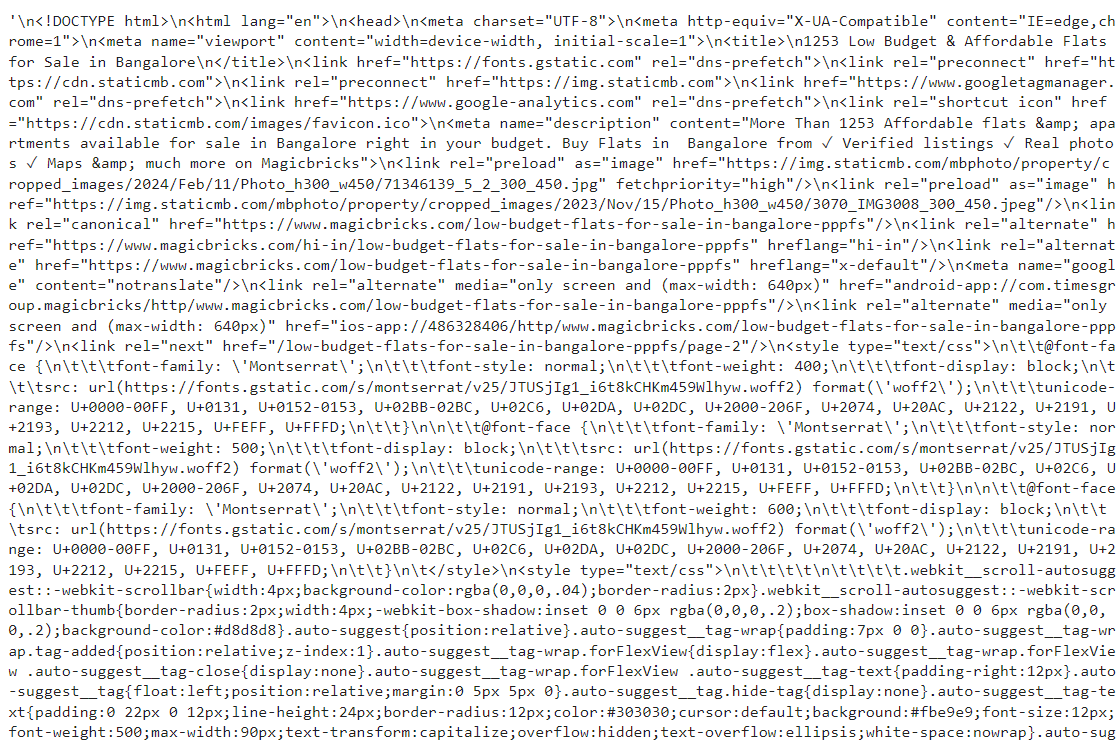

In [2]:
doc

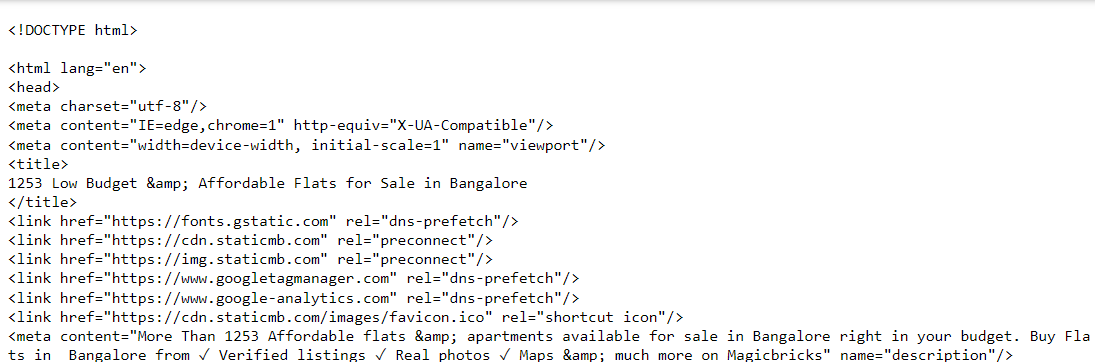

In [10]:
info[1]

<div class="mb-srp__card__info mb-srp__card__info-withoutburger"><h2 class="mb-srp__card--title" title="3 BHK Apartment for Sale in Geleyara Balaga Layout Jalahalli West Bangalore">3 BHK Apartment for Sale in Geleyara Balaga Layout Jalahalli West Bangalore</h2><div class="mb-srp__card__summary" id="propertiesAction68682427"><div class="mb-srp__card__summary__list"><div class="mb-srp__card__summary__list--item" data-summary="carpet-area"><div class="mb-srp__card__summary--label">Carpet Area</div><div class="mb-srp__card__summary--value">1100 sqft</div></div><div class="mb-srp__card__summary__list--item" data-summary="status"><div class="mb-srp__card__summary--label">Status</div><div class="mb-srp__card__summary--value">Ready to Move</div></div><div class="mb-srp__card__summary__list--item" data-summary="floor"><div class="mb-srp__card__summary--label">Floor</div><div class="mb-srp__card__summary--value">3 out of 3</div></div><div class="mb-srp__card__summary__list--item" data-summary="t

In [118]:
for i in range(len(info)):
    labels = info[i].find_all("div", {"class": "mb-srp__card__summary--label"})
labels

[<div class="mb-srp__card__summary--label">Carpet Area</div>,
 <div class="mb-srp__card__summary--label">Status</div>,
 <div class="mb-srp__card__summary--label">Floor</div>,
 <div class="mb-srp__card__summary--label">Transaction</div>,
 <div class="mb-srp__card__summary--label">Furnishing</div>,
 <div class="mb-srp__card__summary--label">facing</div>,
 <div class="mb-srp__card__summary--label">overlooking</div>,
 <div class="mb-srp__card__summary--label">Ownership</div>,
 <div class="mb-srp__card__summary--label">Bathroom</div>,
 <div class="mb-srp__card__summary--label">Balcony</div>]

In [119]:
fields = []
[fields.append(x) for x in labels if x not in fields] 
fields

[<div class="mb-srp__card__summary--label">Carpet Area</div>,
 <div class="mb-srp__card__summary--label">Status</div>,
 <div class="mb-srp__card__summary--label">Floor</div>,
 <div class="mb-srp__card__summary--label">Transaction</div>,
 <div class="mb-srp__card__summary--label">Furnishing</div>,
 <div class="mb-srp__card__summary--label">facing</div>,
 <div class="mb-srp__card__summary--label">overlooking</div>,
 <div class="mb-srp__card__summary--label">Ownership</div>,
 <div class="mb-srp__card__summary--label">Bathroom</div>,
 <div class="mb-srp__card__summary--label">Balcony</div>]

In [120]:
for i in range(len(fields)):
        fields[i] = fields[i].text 
        
fields

['Carpet Area',
 'Status',
 'Floor',
 'Transaction',
 'Furnishing',
 'facing',
 'overlooking',
 'Ownership',
 'Bathroom',
 'Balcony']

In [121]:
df_titles = ['title', 'Society_Name', 'Price', 'Price_Per_sqft'] + fields
df = pd.DataFrame(columns=df_titles)

df

,title,Society_Name,Price,Price_Per_sqft,Carpet Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Ownership,Bathroom,Balcony


### Creating the Dataframe Header

In [129]:
def create_dataframe(): 
    """
    This function creates the dataframe for the values to be extracted from the parsed content. 
    Returns : Dataframe and fields list
    """
    
    url = "https://www.magicbricks.com/low-budget-flats-for-sale-in-bangalore-pppfs" 
    result = requests.get(url) 
    doc = BeautifulSoup(result.text, "html.parser")  
    info = doc.find_all("div", {"class": 'mb-srp__card__info'})
    fields = []
    
    for i in range(len(info)):
        labels = info[i].find_all("div", {"class": "mb-srp__card__summary--label"})
        [fields.append(x) for x in labels if x not in fields]

    for i in range(len(fields)):
        fields[i] = fields[i].text

    df_titles = ['title', 'Society_Name', 'Price', 'Price_Per_sqft'] + fields
    df = pd.DataFrame(columns=df_titles)
    return (df, fields)       

### Web Scrapping 

In [136]:
# Create the dataframe 
df, fields = create_dataframe()


# Loop through 4 pages through urls
for i in range(0,4):
    
    # Per page loads 30 tuples. Thus 30*(page number) is added as index to the dataframe
    page_number = i
    correction = 30*page_number
    
    # Url is updated to access different pages. 
    url = "https://www.magicbricks.com/low-budget-flats-for-sale-in-bangalore-pppfs" + '/page-' + str(i+1)
    
    # Make a request to a web page, and return the status code
    result = requests.get(url) 
    
    # Create a BeautifulSoup object(doc) and pass the HTML document as a string. HTML parser.
    doc = BeautifulSoup(result.text, "html.parser")
    
    # Get the relevant classes
    info = doc.find_all("div", {"class": 'mb-srp__card__info'})
    price_info = doc.find_all("div", {"class": 'mb-srp__card__estimate'})
    
    # Initialize dictionary to None (Different properties have different features. Not all features are present.)
    item_dictionary = {}
    for i in fields:
        item_dictionary[i] = None

    # Loop over to extract relevant features
    for i in range(len(info)):
        val_dict = {}                       
        title = info[i].find("h2", {"class": "mb-srp__card--title"}).text
        society_name = info[i].find("div", {"class": "mb-srp__card__society"})
        # Extract text value if not null value
        if society_name is not None:
            society_name = society_name.text
    
        Price = price_info[i].find("div", {"class": "mb-srp__card__price--amount"}).text

        Price_Per_sqft = price_info[i].find("div", {"class": "mb-srp__card__price--size"})
        if Price_Per_sqft is not None:
            Price_Per_sqft = Price_Per_sqft.text
        
        # Add values to dictionary
        val_dict['title'] = title
        val_dict['Society_Name'] = society_name
        val_dict['Price'] = Price
        val_dict['Price_Per_sqft'] = Price_Per_sqft
        
        # Assign initiated dictionary
        item_dict = item_dictionary 
        
        # Extract labels and respective values
        labels = info[i].find_all("div", {"class": "mb-srp__card__summary--label"})
        values = info[i].find_all("div", {"class": "mb-srp__card__summary--value"})
        
        # Add values tor elevant keys
        for j in range(len(labels)):
            item_dict[labels[j].text] = values[j].text
        
        # Combine both the dictionaries
        final_dict = val_dict | item_dict
        
        # Assign the final dictionary to the dataframe
        df.loc[i + correction] = final_dict 




In [139]:
df.duplicated().value_counts()

False    119
True       1
Name: count, dtype: int64

In [140]:
df.to_csv("bangalore_flat_sales.csv", index=False)

## Data Cleaning

In [16]:
# import spacy 
import pandas as pd             
import numpy as np              
import seaborn as sns              
import os                        
import nltk          
import regex as re
from nltk import word_tokenize
import csv
import matplotlib.pyplot as plt; plt.rcdefaults()
from nltk.corpus import stopwords          
import warnings
warnings.filterwarnings("ignore",category=DeprecationWarning)

In [17]:
df = pd.read_csv("bangalore_flat_sales.csv")

In [18]:
df.head(3)

,title,Society_Name,Price,Price_Per_sqft,Super Area,Status,Floor,Transaction,Furnishing,facing,overlooking,Ownership,Car Parking,Bathroom,Carpet Area,Balcony
0,2 BHK Builder Floor for Sale in Kengeri Bangalore,NaN,₹38 Lac,₹5067 per sqft,750 sqft,Ready to Move,2 out of 4,Resale,Semi-Furnished,South - East,Garden/Park,Freehold,1 Covered,2,NaN,NaN
1,2 BHK Builder Floor for Sale in Bommasandra Ba...,NaN,₹38 Lac,₹4294 per sqft,885 sqft,Ready to Move,1 out of 4,Resale,Semi-Furnished,South - East,Garden/Park,Freehold,1 Covered,2,NaN,NaN
2,1 BHK House for Sale in Vidyaranyapura Bangalore,NaN,₹25 Lac,₹4032 per sqft,885 sqft,Ready to Move,1 out of 4,Resale,Unfurnished,East,Garden/Park,Freehold,1 Covered,1,600 sqft,NaN


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           120 non-null    object 
 1   Society_Name    51 non-null     object 
 2   Price           120 non-null    object 
 3   Price_Per_sqft  110 non-null    object 
 4   Super Area      119 non-null    object 
 5   Status          115 non-null    object 
 6   Floor           111 non-null    object 
 7   Transaction     120 non-null    object 
 8   Furnishing      120 non-null    object 
 9   facing          109 non-null    object 
 10  overlooking     82 non-null     object 
 11  Ownership       109 non-null    object 
 12  Car Parking     115 non-null    object 
 13  Bathroom        120 non-null    int64  
 14  Carpet Area     104 non-null    object 
 15  Balcony         105 non-null    float64
dtypes: float64(1), int64(1), object(14)
memory usage: 15.1+ KB


In [20]:
# Check for duplicates 
df.duplicated().value_counts()

False    119
True       1
Name: count, dtype: int64

In [21]:
# Remove Duplicates 
df = df.drop_duplicates()

In [22]:
# Add units to the headers 
df = df.rename(columns = {
    'Price':'Price(Lac)',
    'Price_Per_sqft':'Price_Per_sqft(rs)', 
    'Carpet Area':'Carpet Area(sqft)',
    'Super Area':'Super Area(sqft)',
    
    })  

In [23]:
df.head(2)

,title,Society_Name,Price(Lac),Price_Per_sqft(rs),Super Area(sqft),Status,Floor,Transaction,Furnishing,facing,overlooking,Ownership,Car Parking,Bathroom,Carpet Area(sqft),Balcony
0,2 BHK Builder Floor for Sale in Kengeri Bangalore,NaN,₹38 Lac,₹5067 per sqft,750 sqft,Ready to Move,2 out of 4,Resale,Semi-Furnished,South - East,Garden/Park,Freehold,1 Covered,2,NaN,NaN
1,2 BHK Builder Floor for Sale in Bommasandra Ba...,NaN,₹38 Lac,₹4294 per sqft,885 sqft,Ready to Move,1 out of 4,Resale,Semi-Furnished,South - East,Garden/Park,Freehold,1 Covered,2,NaN,NaN


In [24]:
df.isnull().sum()

title                  0
Society_Name          68
Price(Lac)             0
Price_Per_sqft(rs)    10
Super Area(sqft)       1
Status                 5
Floor                  9
Transaction            0
Furnishing             0
facing                11
overlooking           37
Ownership             11
Car Parking            5
Bathroom               0
Carpet Area(sqft)     16
Balcony               15
dtype: int64

In [512]:
# Data Cleaning Experimentation
print("-------------------------value------------------------", "\n")
x = df['title'].loc[0]
print(x,"\n")  
print("------------------------Removing BHK-------- ---------","\n")
bhk_removed = re.sub(r'[[^[0-9] BHK ]*','', x)
print(bhk_removed, "\n") 
print("-----------------Extract Type and Location------------","\n")
type_, location = re.split(' for Sale in ',bhk_removed)
print("type:",type_,"\n","Location:" ,location)

-------------------------value------------------------ 

2 BHK Builder Floor for Sale in Kengeri Bangalore 

------------------------Removing BHK-------- --------- 

Builder Floor for Sale in Kengeri Bangalore 

-----------------Extract Type and Location------------ 

type: Builder Floor 
 Location: Kengeri Bangalore


#### Remove symbols 

In [25]:
def remove_initial_text(text):
    txt = text[1:]         
    return txt 

In [26]:
df['Price(Lac)'] = df['Price(Lac)'].apply(lambda x: remove_initial_text(x))
df['Price_Per_sqft(rs)'] = df['Price_Per_sqft(rs)'].apply(lambda x: remove_initial_text(str(x)))

In [27]:
df[['Price(Lac)', 'Price_Per_sqft(rs)']].head(3)

,Price(Lac),Price_Per_sqft(rs)
0,38 Lac,5067 per sqft
1,38 Lac,4294 per sqft
2,25 Lac,4032 per sqft


#### Remove units from values

In [28]:
def remove_alphabets(text):
    """
        Used to remove units present in the values
    """
    return re.sub(r"[A-Za-z\t]", '', text) 

In [29]:
df['Price(Lac)'] = df['Price(Lac)'].apply(lambda x: remove_alphabets(x))
df['Price_Per_sqft(rs)'] = df['Price_Per_sqft(rs)'].apply(lambda x: remove_alphabets(str(x)))
df['Super Area(sqft)'] = df['Super Area(sqft)'].apply(lambda x: remove_alphabets(str(x)))
df['Carpet Area(sqft)'] = df['Carpet Area(sqft)'].apply(lambda x: remove_alphabets(str(x)))

In [30]:
df[['Price(Lac)', 'Price_Per_sqft(rs)', 'Super Area(sqft)', 'Carpet Area(sqft)']].head()

,Price(Lac),Price_Per_sqft(rs),Super Area(sqft),Carpet Area(sqft)
0,38,5067,750,
1,38,4294,885,
2,25,4032,885,600
3,35.1,5433,646,600
4,36,4966,646,675


### Extract different features from 'Title'

In [31]:
df['title'].head(10)

0    2 BHK Builder Floor for Sale in Kengeri Bangalore
1    2 BHK Builder Floor for Sale in Bommasandra Ba...
2     1 BHK House for Sale in Vidyaranyapura Bangalore
3    1 BHK Apartment for Sale in Nagavarapalya, CV ...
4    2 BHK Apartment for Sale in Jalahalli West Ban...
5    2 BHK Apartment for Sale in Sarjapur Road Bang...
6    1 BHK Apartment for Sale in Austin Town Bangalore
7    1 BHK Apartment for Sale in Yelahanka New Town...
8         2 BHK Apartment for Sale in Anekal Bangalore
9    2 BHK Builder Floor for Sale in RT Nagar Banga...
Name: title, dtype: object

In [32]:
def extract_bhk(text):
    txt = re.findall(r'[0-9] BHK',text)
    if(len(txt)) > 0:
        return txt[0]
    else:
        return None 

df['BHK'] = df['title'].apply(lambda x: extract_bhk(str(x)))
    

In [33]:
df['BHK'].value_counts()

BHK
2 BHK    62
1 BHK    31
3 BHK    13
4 BHK     7
5 BHK     1
Name: count, dtype: int64

In [34]:
df.head(3)

,title,Society_Name,Price(Lac),Price_Per_sqft(rs),Super Area(sqft),Status,Floor,Transaction,Furnishing,facing,overlooking,Ownership,Car Parking,Bathroom,Carpet Area(sqft),Balcony,BHK
0,2 BHK Builder Floor for Sale in Kengeri Bangalore,NaN,38,5067,750,Ready to Move,2 out of 4,Resale,Semi-Furnished,South - East,Garden/Park,Freehold,1 Covered,2,,NaN,2 BHK
1,2 BHK Builder Floor for Sale in Bommasandra Ba...,NaN,38,4294,885,Ready to Move,1 out of 4,Resale,Semi-Furnished,South - East,Garden/Park,Freehold,1 Covered,2,,NaN,2 BHK
2,1 BHK House for Sale in Vidyaranyapura Bangalore,NaN,25,4032,885,Ready to Move,1 out of 4,Resale,Unfurnished,East,Garden/Park,Freehold,1 Covered,1,600,NaN,1 BHK


In [35]:
def extract_type_loc(text):
    bhk_removed = re.sub(r'[[^[0-9] BHK ]*','', text)
    type_, location = re.split(' for Sale in ',bhk_removed)
    return type_, location

In [36]:
type_loc = df['title'].apply(lambda x: extract_type_loc(str(x)))

In [37]:
type_loc

0                     (Builder Floor, Kengeri Bangalore)
1                 (Builder Floor, Bommasandra Bangalore)
2                      (House, Vidyaranyapura Bangalore)
3      (Apartment, Nagavarapalya, CV Raman Nagar Bang...
4                  (Apartment, Jalahalli West Bangalore)
                             ...                        
115                   (Apartment, Bommasandra Bangalore)
116    (Builder Floor, Nisarga Layout Chikkalasandra ...
117                (Apartment, Doddaballapura Bangalore)
118                 (Apartment, Sarjapur Road Bangalore)
119                    (Apartment, Whitefield Bangalore)
Name: title, Length: 119, dtype: object

In [38]:
df['Floor'].isnull().sum()

9

In [39]:
type_li = []
location_li = []
for i in type_loc:
    type_li.append(i[0])
    location_li.append(i[1])
    
df['Type'] = type_li 
df['Location'] = location_li

In [74]:
df[['Type', 'Location']].head(3)

,Type,Location
0,Builder Floor,Kengeri Bangalore
1,Builder Floor,Bommasandra Bangalore
2,House,Vidyaranyapura Bangalore


In [41]:
df['Floor'].head(3)

0    2 out of 4
1    1 out of 4
2    1 out of 4
Name: Floor, dtype: object

In [42]:
df['Floor'].value_counts()

Floor
2 out of 4                 14
1 out of 4                  8
2 out of 6                  8
1 out of 3                  7
1 out of 5                  5
3 out of 4                  4
2 out of 5                  4
5 out of 8                  3
1 out of 6                  3
4 out of 5                  3
3 out of 5                  3
Ground out of 4             3
3 out of 3                  3
2 out of 3                  3
4 out of 13                 2
Ground out of 5             2
Ground out of 7             2
3 out of 9                  2
6 out of 12                 2
2 out of 2                  2
Ground out of 3             2
8 out of 9                  2
9 out of 13                 2
6 out of 9                  1
6 out of 8                  1
2 out of 10                 1
Upper Basement out of 4     1
7 out of 7                  1
Ground out of 1             1
Ground out of 2             1
2 out of 12                 1
3 out of 6                  1
4 out of 9                  1
5 ou

In [43]:
text = df['Floor'].loc[0]
print(text)
floors = re.split(' out of ',text)
print(floors)

2 out of 4
['2', '4']


In [44]:
c = df['Floor'].apply(lambda x: re.split(' out of ', str(x)))

In [45]:
len(df)

119

In [46]:
c

0       [2, 4]
1       [1, 4]
2       [1, 4]
3       [5, 5]
4       [1, 4]
        ...   
115     [1, 5]
116     [1, 4]
117     [7, 7]
118     [8, 9]
119    [9, 14]
Name: Floor, Length: 119, dtype: object

In [47]:
x = []
for i in c:
    x.append(i[1])

IndexError: list index out of range

In [48]:
# Extract floor number and total floors 
def floor_split(text):
    floor_features = re.split(' out of ',text)
    return floor_features
    
floor_features = df['Floor'].apply(lambda x: floor_split(str(x))) 
      
available_floor, total_floors = [],[]
for i in floor_features:
    try:
        available_floor.append(i[0])
    except:
        available_floor.append(None)
    try:    
        total_floors.append(i[1])
    except:
        total_floors.append(None)
    
df['Floor_Available']  =   available_floor 
df['Total Floors in Building']  = total_floors                             

In [75]:
df[['Floor_Available', 'Total Floors in Building']].head(3)

,Floor_Available,Total Floors in Building
0,2,4
1,1,4
2,1,4


In [49]:
cols = ['Price(Lac)', 'Price_Per_sqft(rs)', 'Super Area(sqft)', 'Bathroom', 'Carpet Area(sqft)']

In [50]:
for i in cols:
    print(df[i].value_counts())

Price(Lac)
35        9
36        7
          7
38        6
40        6
28        5
25        4
24        4
29        3
37        3
27        3
30        3
34        3
33        3
18        3
42        3
41        3
39        3
23        3
43        2
32        2
17        2
22        2
12        1
23.3      1
19        1
34.9      1
23.2      1
13.1      1
13        1
12.9      1
16.5      1
13.5      1
13.4      1
13.3      1
13.2      1
12.8      1
23.5      1
20        1
23.4      1
23.1      1
38.4      1
16.9      1
16.8      1
16.7      1
16.6      1
5.5       1
25.5      1
16        1
30.6      1
37.7      1
35.1      1
31        1
Name: count, dtype: int64
Price_Per_sqft(rs)
999        21
           10
4000        3
5325        2
4444        2
           ..
3590        1
4754        1
3811        1
9467        1
5321        1
Name: count, Length: 84, dtype: int64
Super Area(sqft)
900      10
642       6
1000      5
1200      5
650       4
         ..
2340      1
326       1
235

* 'Price(Lac)', 'Price_Per_sqft(rs)', 'Super Area(sqft)','Carpet Area(sqft)' has empty strings.

#### 'Price(Lac)'

In [51]:
df[df['Price(Lac)'] == '  ']

,title,Society_Name,Price(Lac),Price_Per_sqft(rs),Super Area(sqft),Status,Floor,Transaction,Furnishing,facing,...,Ownership,Car Parking,Bathroom,Carpet Area(sqft),Balcony,BHK,Type,Location,Floor_Available,Total Floors in Building
38,2 BHK House for Sale in Rajajinagar Bangalore,NaN,,,1200,Ready to Move,Ground out of 2,Resale,Semi-Furnished,North,...,Freehold,1 Covered,2,600,1.0,2 BHK,House,Rajajinagar Bangalore,Ground,2
46,3 BHK Apartment for Sale in Chikkabanavara Ban...,Janapriya Greenwood,,,900,Ready to Move,2 out of 4,Resale,Furnished,North - East,...,Freehold,1 Covered,3,1360,2.0,3 BHK,Apartment,Chikkabanavara Bangalore,2,4
47,2 BHK Villa for Sale in Kanakapura Road Bangalore,NaN,,,900,Ready to Move,2 out of 4,Resale,Semi-Furnished,North - East,...,Freehold,1 Covered,2,1200,2.0,2 BHK,Villa,Kanakapura Road Bangalore,2,4
59,1 BHK Apartment for Sale in Jigani Bangalore,NaN,,,700,Ready to Move,2 out of 4,New Property,Unfurnished,North,...,Freehold,1 Covered,1,600,1.0,1 BHK,Apartment,Jigani Bangalore,2,4
61,2 BHK Apartment for Sale in Hebbal Bangalore,NaN,,,850,Ready to Move,1 out of 4,Resale,Unfurnished,East,...,Freehold,NaN,1,1100,1.0,2 BHK,Apartment,Hebbal Bangalore,1,4
79,3 BHK Apartment for Sale in Phase 7 JP Nagar B...,NaN,,,1495,Ready to Move,9 out of 13,Resale,Unfurnished,North,...,Freehold,1 Covered,3,830,2.0,3 BHK,Apartment,Phase 7 JP Nagar Bangalore,9,13
88,2 BHK Apartment for Sale in Yelahanka Bangalore,NaN,,,1650,Ready to Move,Ground out of 7,Resale,Semi-Furnished,North,...,Freehold,1 Open,2,700,1.0,2 BHK,Apartment,Yelahanka Bangalore,Ground,7


In [52]:
indx = df[df['Price(Lac)'] == '  '].index

In [53]:
for i in indx:
    df.loc[i,'Price(Lac)'] = 0 
    df.loc[i,'Price_Per_sqft(rs)'] = 0

In [54]:
df[df['Price(Lac)'] == None]

,title,Society_Name,Price(Lac),Price_Per_sqft(rs),Super Area(sqft),Status,Floor,Transaction,Furnishing,facing,...,Ownership,Car Parking,Bathroom,Carpet Area(sqft),Balcony,BHK,Type,Location,Floor_Available,Total Floors in Building


#### 'Price_Per_sqft(rs)'

In [55]:
df[df['Price_Per_sqft(rs)'] == '']

,title,Society_Name,Price(Lac),Price_Per_sqft(rs),Super Area(sqft),Status,Floor,Transaction,Furnishing,facing,...,Ownership,Car Parking,Bathroom,Carpet Area(sqft),Balcony,BHK,Type,Location,Floor_Available,Total Floors in Building
40,2 BHK Apartment for Sale in Thattanahalli Bang...,Artha Citrine,25.5,,1200,Ready to Move,Ground out of 3,Resale,Furnished,North,...,Freehold,1 Covered,1,490,1.0,2 BHK,Apartment,Thattanahalli Bangalore,Ground,3
108,2 BHK Apartment for Sale in Chandapura Bangalore,Karsten Palm Groves,33,,375,Ready to Move,2 out of 10,Resale,Semi-Furnished,North,...,Freehold,1 Covered,2,698,2.0,2 BHK,Apartment,Chandapura Bangalore,2,10
109,3 BHK Apartment for Sale in Geleyara Balaga La...,NaN,39,,375,Ready to Move,3 out of 3,Resale,Semi-Furnished,North,...,Freehold,1 Covered,2,1100,1.0,3 BHK,Apartment,Geleyara Balaga Layout Jalahalli West Bangalore,3,3


In [56]:
indx2 = df[df['Price_Per_sqft(rs)'] == ''].index 
for i in indx2:
    df.loc[i, 'Price_Per_sqft(rs)'] = 0


In [57]:
df[df['Super Area(sqft)'] == '']

,title,Society_Name,Price(Lac),Price_Per_sqft(rs),Super Area(sqft),Status,Floor,Transaction,Furnishing,facing,...,Ownership,Car Parking,Bathroom,Carpet Area(sqft),Balcony,BHK,Type,Location,Floor_Available,Total Floors in Building
60,2 BHK Apartment for Sale in Electronic City Ba...,NaN,29,2266,,Ready to Move,1 out of 4,New Property,Unfurnished,East,...,Freehold,NaN,2,1100,1.0,2 BHK,Apartment,Electronic City Bangalore,1,4


In [58]:
df.loc[60, 'Super Area(sqft)'] = 0

In [59]:
df[df['Carpet Area(sqft)'] == ''].head()

,title,Society_Name,Price(Lac),Price_Per_sqft(rs),Super Area(sqft),Status,Floor,Transaction,Furnishing,facing,...,Ownership,Car Parking,Bathroom,Carpet Area(sqft),Balcony,BHK,Type,Location,Floor_Available,Total Floors in Building
0,2 BHK Builder Floor for Sale in Kengeri Bangalore,NaN,38,5067,750,Ready to Move,2 out of 4,Resale,Semi-Furnished,South - East,...,Freehold,1 Covered,2,,NaN,2 BHK,Builder Floor,Kengeri Bangalore,2,4
1,2 BHK Builder Floor for Sale in Bommasandra Ba...,NaN,38,4294,885,Ready to Move,1 out of 4,Resale,Semi-Furnished,South - East,...,Freehold,1 Covered,2,,NaN,2 BHK,Builder Floor,Bommasandra Bangalore,1,4
30,5 BHK House for Sale in Konanakunte Bangalore,NaN,18,2250,800,Ready to Move,NaN,Resale,Unfurnished,NaN,...,NaN,NaN,3,,NaN,5 BHK,House,Konanakunte Bangalore,nan,None
31,Studio Apartment for Sale in Bagaluru Bangalore,NaN,33,17277,191,Ready to Move,NaN,New Property,Unfurnished,NaN,...,NaN,1 Covered,3,,NaN,None,Studio Apartment,Bagaluru Bangalore,nan,None
32,Studio Apartment for Sale in Bagaluru Bangalore,NaN,34,17801,191,Ready to Move,NaN,New Property,Unfurnished,NaN,...,NaN,1 Covered,3,,NaN,None,Studio Apartment,Bagaluru Bangalore,nan,None


In [60]:
indx3 = df[df['Carpet Area(sqft)'] == ''].index 

for i in indx3:
    df.loc[i, 'Carpet Area(sqft)'] = 0

In [61]:
# Convert string to int for relevant columns
def str_to_int(column):
    try:
        df[column] = df[column].astype(int)
    except:
        pass                                                                       

cols = ['Price_Per_sqft(rs)', 'Super Area(sqft)', 'Bathroom', 'Carpet Area(sqft)']

In [62]:
df['Price(Lac)'] = df['Price(Lac)'].astype(float)
df['Price_Per_sqft(rs)'] = df['Price_Per_sqft(rs)'].astype(float)   
df['Bathroom'] = df['Bathroom'].astype(int)
df['Carpet Area(sqft)'] = df['Carpet Area(sqft)'].astype(float)                           

In [67]:
df.head()                                                            

,title,Society_Name,Price(Lac),Price_Per_sqft(rs),Super Area(sqft),Status,Floor,Transaction,Furnishing,facing,...,Ownership,Car Parking,Bathroom,Carpet Area(sqft),Balcony,BHK,Type,Location,Floor_Available,Total Floors in Building
0,2 BHK Builder Floor for Sale in Kengeri Bangalore,NaN,38.0,5067.0,750,Ready to Move,2 out of 4,Resale,Semi-Furnished,South - East,...,Freehold,1 Covered,2,0.0,NaN,2 BHK,Builder Floor,Kengeri Bangalore,2,4
1,2 BHK Builder Floor for Sale in Bommasandra Ba...,NaN,38.0,4294.0,885,Ready to Move,1 out of 4,Resale,Semi-Furnished,South - East,...,Freehold,1 Covered,2,0.0,NaN,2 BHK,Builder Floor,Bommasandra Bangalore,1,4
2,1 BHK House for Sale in Vidyaranyapura Bangalore,NaN,25.0,4032.0,885,Ready to Move,1 out of 4,Resale,Unfurnished,East,...,Freehold,1 Covered,1,600.0,NaN,1 BHK,House,Vidyaranyapura Bangalore,1,4
3,"1 BHK Apartment for Sale in Nagavarapalya, CV ...",MYJ Residency,35.1,5433.0,646,Ready to Move,5 out of 5,Resale,Semi-Furnished,East,...,Freehold,1 Covered,1,600.0,NaN,1 BHK,Apartment,"Nagavarapalya, CV Raman Nagar Bangalore",5,5
4,2 BHK Apartment for Sale in Jalahalli West Ban...,Commanders Glory,36.0,4966.0,646,Ready to Move,1 out of 4,Resale,Semi-Furnished,North,...,Freehold,"1 Covered,",1,675.0,1.0,2 BHK,Apartment,Jalahalli West Bangalore,1,4


In [68]:
# Drop extra columns
df = df.drop(['title', 'Floor'], axis= 1)

### Finalized DataFrame

In [70]:
df.head()

,Society_Name,Price(Lac),Price_Per_sqft(rs),Super Area(sqft),Status,Transaction,Furnishing,facing,overlooking,Ownership,Car Parking,Bathroom,Carpet Area(sqft),Balcony,BHK,Type,Location,Floor_Available,Total Floors in Building
0,NaN,38.0,5067.0,750,Ready to Move,Resale,Semi-Furnished,South - East,Garden/Park,Freehold,1 Covered,2,0.0,NaN,2 BHK,Builder Floor,Kengeri Bangalore,2,4
1,NaN,38.0,4294.0,885,Ready to Move,Resale,Semi-Furnished,South - East,Garden/Park,Freehold,1 Covered,2,0.0,NaN,2 BHK,Builder Floor,Bommasandra Bangalore,1,4
2,NaN,25.0,4032.0,885,Ready to Move,Resale,Unfurnished,East,Garden/Park,Freehold,1 Covered,1,600.0,NaN,1 BHK,House,Vidyaranyapura Bangalore,1,4
3,MYJ Residency,35.1,5433.0,646,Ready to Move,Resale,Semi-Furnished,East,Garden/Park,Freehold,1 Covered,1,600.0,NaN,1 BHK,Apartment,"Nagavarapalya, CV Raman Nagar Bangalore",5,5
4,Commanders Glory,36.0,4966.0,646,Ready to Move,Resale,Semi-Furnished,North,"Garden/Park, Main Road",Freehold,"1 Covered,",1,675.0,1.0,2 BHK,Apartment,Jalahalli West Bangalore,1,4


In [71]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 119 entries, 0 to 119
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Society_Name              51 non-null     object 
 1   Price(Lac)                119 non-null    float64
 2   Price_Per_sqft(rs)        119 non-null    float64
 3   Super Area(sqft)          119 non-null    object 
 4   Status                    114 non-null    object 
 5   Transaction               119 non-null    object 
 6   Furnishing                119 non-null    object 
 7   facing                    108 non-null    object 
 8   overlooking               82 non-null     object 
 9   Ownership                 108 non-null    object 
 10  Car Parking               114 non-null    object 
 11  Bathroom                  119 non-null    int32  
 12  Carpet Area(sqft)         119 non-null    float64
 13  Balcony                   104 non-null    float64
 14  BHK            

### Conclusion  

Web scraping and data cleaning are indispensable components of the data lifecycle, enabling organizations and researchers to harness the power of online data while ensuring its integrity and reliability for informed decision-making and analysis.